# Sport Recife 2026 — Força dos Adversários vs xG

Módulo 2: investiga se a deterioração do xG coincidiu com aumento da força dos adversários.

**Metodologia de força:**
- `market_value_score`: valor de mercado do elenco (Sofascore), normalizado 0–1
- `perf_score`: pontos por jogo do adversário em 2026, normalizado 0–1
- `strength_score`: média ponderada (60% market value + 40% desempenho)
- Adversários sem valor de mercado (AD Jaguar): score baseado apenas em desempenho

In [1]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

RESULTS_PATH  = Path('../data/processed/2026/sport/sport_2026_results.csv')
STATS_PATH    = Path('../data/processed/2026/sport/sport_2026_team_match_stats.csv')
OPP_STR_PATH  = Path('../data/processed/2026/sport/sport_2026_opponent_strength.csv')
OUTPUT_DIR    = Path('../data/processed/2026/sport')

TEAM_NAME        = 'Sport Recife'
FASE1_N_JOGOS    = 3
SERIE_B_DEBUT_TS = pd.Timestamp('2026-03-21T23:30:00', tz='UTC')

FASE_LABELS = {1: 'Fase 1 — Sub20', 2: 'Fase 2 — Pré-Série B', 3: 'Fase 3 — Márcio Goiano'}
FASE_COLORS = {1: '#D97706', 2: '#0369A1', 3: '#047857'}
FASE_BG     = {1: '#FDE68A', 2: '#BAE6FD', 3: '#BBF7D0'}

In [2]:
# ── Carrega e prepara results ─────────────────────────────────────────────────
results = pd.read_csv(RESULTS_PATH)
results['match_date_utc'] = pd.to_datetime(results['match_date_utc'], utc=True)
results = results.sort_values('match_date_utc').reset_index(drop=True)
results['jogo_num'] = range(1, len(results) + 1)

def assign_phase(row):
    if row['jogo_num'] <= FASE1_N_JOGOS: return 1
    elif row['match_date_utc'] <= SERIE_B_DEBUT_TS: return 2
    else: return 3

results['fase'] = results.apply(assign_phase, axis=1)
results['opponent'] = results.apply(
    lambda r: r['away_team'] if r['home_team'] == TEAM_NAME else r['home_team'], axis=1
)
results['label'] = results['jogo_num'].astype(str) + '. ' + results['opponent'].str.split().str[0]

# ── xG a favor e contra ───────────────────────────────────────────────────────
team_stats = pd.read_csv(STATS_PATH)
sport_xg = (
    team_stats.loc[team_stats['team_name'].eq(TEAM_NAME)]
    .drop_duplicates('source_url')
    [['source_url','expected_goals']].rename(columns={'expected_goals': 'xg_for'})
)
opp_xg = (
    team_stats.loc[~team_stats['team_name'].eq(TEAM_NAME)]
    .drop_duplicates('source_url')
    [['source_url','expected_goals']].rename(columns={'expected_goals': 'xg_against'})
)
results = results.merge(sport_xg, on='source_url', how='left')
results = results.merge(opp_xg,   on='source_url', how='left')
results['xg_diff'] = results['xg_for'] - results['xg_against']

# ── Força dos adversários ─────────────────────────────────────────────────────
opp_str = pd.read_csv(OPP_STR_PATH)

# Normaliza market value (min-max, ignora NaN)
mv = opp_str['squad_market_value_eur']
mv_min, mv_max = mv.min(), mv.max()
opp_str['market_value_score'] = (mv - mv_min) / (mv_max - mv_min)

# Normaliza pontos por jogo
ppg = opp_str['perf_points_per_game'].fillna(0)
ppg_max = ppg.max() if ppg.max() > 0 else 1
opp_str['perf_score'] = ppg / ppg_max

# Score composto: onde há market value usa 60/40, senão só perf
def composite_score(row):
    if pd.notna(row['market_value_score']):
        return 0.60 * row['market_value_score'] + 0.40 * row['perf_score']
    return row['perf_score']

opp_str['strength_score'] = opp_str.apply(composite_score, axis=1)

# Merge com results
df = results.merge(
    opp_str[['opponent_name','squad_market_value_eur','perf_points_per_game',
             'market_value_score','perf_score','strength_score','perf_win_rate','perf_games']],
    left_on='opponent', right_on='opponent_name', how='left'
)

print(df[['jogo_num','fase','label','xg_for','xg_diff',
          'squad_market_value_eur','strength_score']].to_string(index=False))

 jogo_num  fase          label  xg_for  xg_diff  squad_market_value_eur  strength_score
        1     1          1. AD    1.74     0.94                     NaN            0.22
        2     1       2. Retrô     NaN      NaN              3064000.00            0.52
        3     1     3. Náutico    3.08     2.39              7765000.00            0.84
        4     2     4. Decisão    3.02     2.53               725000.00            0.03
        5     2   5. Acadêmica    2.75     2.75               188000.00            0.00
        6     2     6. Maguary    1.62    -0.26              1263000.00            0.12
        7     2       7. Santa    2.41     1.36              5993000.00            0.34
        8     2       8. Retrô     NaN      NaN              3064000.00            0.52
        9     2       9. Retrô     NaN      NaN              3064000.00            0.52
       10     2    10. Náutico    0.69    -2.39              7765000.00            0.84
       11     2 11. Desportiva  

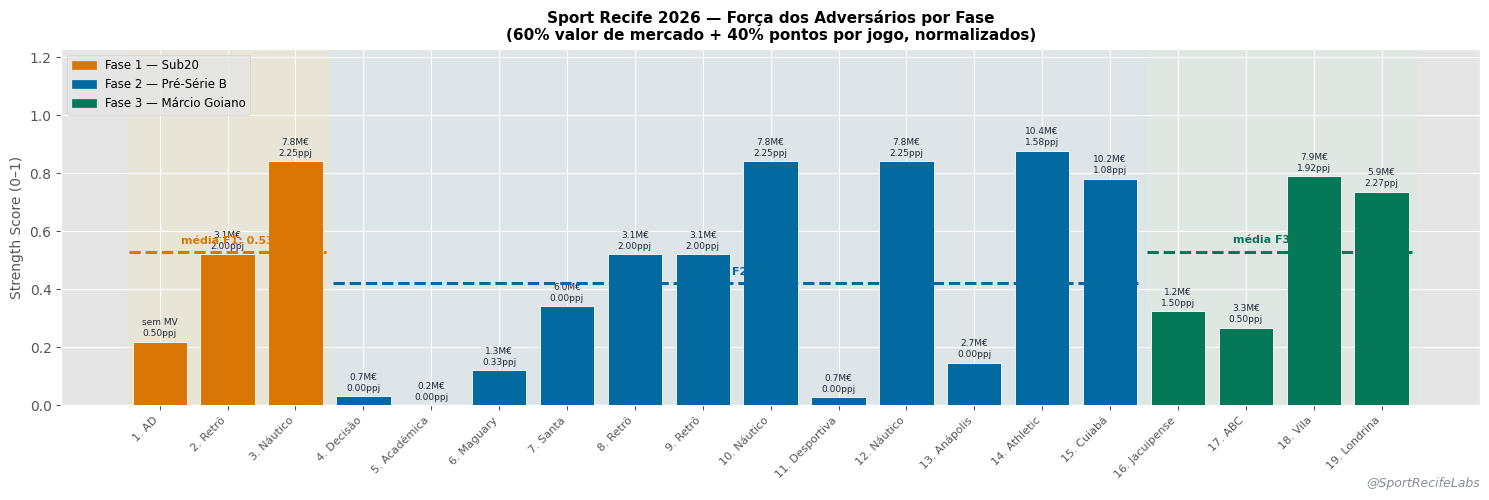

Salvo em ..\data\processed\2026\sport\sport_2026_forca_adversarios.png


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# GRÁFICO 1 — Força dos adversários por fase (ranking visual)
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(15, 5))

bar_colors = [FASE_COLORS[row['fase']] for _, row in df.iterrows()]
bars = ax.bar(df['jogo_num'], df['strength_score'], color=bar_colors,
               edgecolor='white', linewidth=0.6, zorder=3)

# Anotação: valor de mercado em M€ + pontos por jogo
for _, row in df.iterrows():
    ss = row.get('strength_score')
    if pd.isna(ss): continue
    mv = row.get('squad_market_value_eur')
    ppg_val = row.get('perf_points_per_game')
    mv_text = f'{mv/1e6:.1f}M€' if pd.notna(mv) else 'sem MV'
    ppg_text = f'{ppg_val:.2f}ppj' if pd.notna(ppg_val) else ''
    ax.text(row['jogo_num'], ss + 0.012, f'{mv_text}\n{ppg_text}',
            ha='center', va='bottom', fontsize=6.5, color='#1F2937', linespacing=1.3)

# Média por fase
for fase_id in sorted(df['fase'].unique()):
    sub = df.loc[df['fase'] == fase_id, 'strength_score'].dropna()
    game_ids = df.loc[df['fase'] == fase_id, 'jogo_num'].values
    if sub.empty: continue
    ax.hlines(sub.mean(), game_ids.min() - 0.45, game_ids.max() + 0.45,
              color=FASE_COLORS[fase_id], linewidth=2.2, linestyle='--', zorder=4)
    ax.text(game_ids.mean(), sub.mean() + 0.03,
            f'média F{fase_id}: {sub.mean():.2f}',
            ha='center', fontsize=8, color=FASE_COLORS[fase_id], fontweight='bold')

# Faixas de fase
for fase_id in sorted(df['fase'].unique()):
    g = df.loc[df['fase'] == fase_id, 'jogo_num']
    ax.axvspan(g.min() - 0.5, g.max() + 0.5, color=FASE_BG[fase_id], alpha=0.15, zorder=0)

ax.set_xticks(df['jogo_num'])
ax.set_xticklabels(df['label'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Strength Score (0–1)', fontsize=10)
ax.set_ylim(0, df['strength_score'].max() * 1.4)
ax.set_title('Sport Recife 2026 — Força dos Adversários por Fase\n'
             '(60% valor de mercado + 40% pontos por jogo, normalizados)',
             fontsize=11, fontweight='bold')

legend_handles = [mpatches.Patch(color=FASE_COLORS[f], label=FASE_LABELS[f]) for f in sorted(df['fase'].unique())]
ax.legend(handles=legend_handles, fontsize=8.5, loc='upper left')
fig.text(0.99, 0.01, '@SportRecifeLabs', ha='right', va='bottom',
         fontsize=9, color='#6B7280', alpha=0.8, style='italic')

plt.tight_layout()
out1 = OUTPUT_DIR / 'sport_2026_forca_adversarios.png'
plt.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em {out1}')

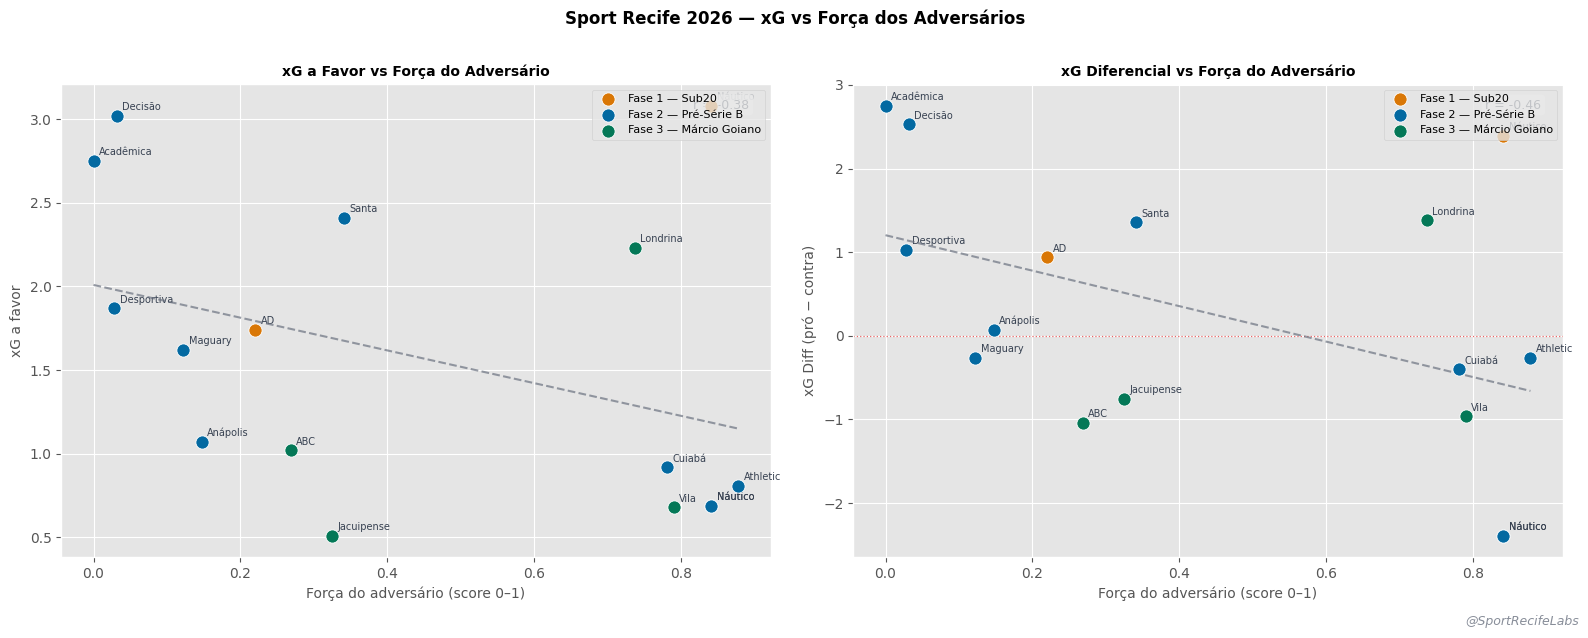

Salvo em ..\data\processed\2026\sport\sport_2026_xg_vs_forca.png


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# GRÁFICO 2 — xG pró vs Força do adversário (scatter por fase)
# ══════════════════════════════════════════════════════════════════════════════

plot_df = df.dropna(subset=['xg_for', 'strength_score']).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_i, (ycol, ylabel, title_suffix) in enumerate([
    ('xg_for',  'xG a favor',    'xG a Favor vs Força do Adversário'),
    ('xg_diff', 'xG Diff (pró − contra)', 'xG Diferencial vs Força do Adversário'),
]):
    ax = axes[ax_i]
    sub = plot_df.dropna(subset=[ycol])

    for fase_id in sorted(sub['fase'].unique()):
        fsub = sub.loc[sub['fase'] == fase_id]
        ax.scatter(fsub['strength_score'], fsub[ycol],
                   color=FASE_COLORS[fase_id], s=90, zorder=5,
                   edgecolors='white', linewidths=0.6,
                   label=FASE_LABELS[fase_id])
        # Rótulo de cada ponto
        for _, row in fsub.iterrows():
            ax.annotate(row['label'].split('. ')[1],
                        xy=(row['strength_score'], row[ycol]),
                        xytext=(4, 4), textcoords='offset points',
                        fontsize=7, color='#374151')

    # Linha de regressão geral
    x_reg = sub['strength_score'].values
    y_reg = sub[ycol].values
    if len(x_reg) > 2:
        coef = np.polyfit(x_reg, y_reg, 1)
        x_line = np.linspace(x_reg.min(), x_reg.max(), 100)
        ax.plot(x_line, np.polyval(coef, x_line),
                color='#6B7280', linewidth=1.5, linestyle='--', alpha=0.7, zorder=3)
        r = np.corrcoef(x_reg, y_reg)[0, 1]
        ax.text(0.97, 0.97, f'r = {r:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='#374151',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    if ax_i == 1:
        ax.axhline(0, color='#DC2626', linewidth=0.9, linestyle=':', alpha=0.7)

    ax.set_xlabel('Força do adversário (score 0–1)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title_suffix, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Sport Recife 2026 — xG vs Força dos Adversários',
             fontsize=12, fontweight='bold', y=1.01)
fig.text(0.99, -0.02, '@SportRecifeLabs', ha='right', va='bottom',
         fontsize=9, color='#6B7280', alpha=0.8, style='italic')

plt.tight_layout()
out2 = OUTPUT_DIR / 'sport_2026_xg_vs_forca.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em {out2}')

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# TABELA RESUMO — xG médio e força média por fase
# ══════════════════════════════════════════════════════════════════════════════

summary = (
    df.groupby('fase')
    .agg(
        jogos=('jogo_num', 'count'),
        xg_medio=('xg_for', 'mean'),
        xg_diff_medio=('xg_diff', 'mean'),
        forca_media=('strength_score', 'mean'),
        mv_medio_M=('squad_market_value_eur', lambda x: x.mean() / 1e6),
        ppg_adversario=('perf_points_per_game', 'mean'),
    )
    .rename(index=lambda f: FASE_LABELS[f])
)
summary.columns = ['Jogos', 'xG médio', 'xG Diff médio', 'Força média',
                   'MV médio (M€)', 'PPJ adversário']
print('=== Resumo por fase ===')
display(summary.round(3))

print('\n=== Ranking de força dos adversários ===')
ranking = (
    opp_str[['opponent_name','squad_market_value_eur','perf_points_per_game',
              'market_value_score','perf_score','strength_score']]
    .sort_values('strength_score', ascending=False)
    .reset_index(drop=True)
)
ranking.index += 1
ranking.columns = ['Adversário','MV (€)','PPJ','MV Score','Perf Score','Strength Score']
display(ranking.round(3))

=== Resumo por fase ===


,Jogos,xG médio,xG Diff médio,Força média,MV médio (M€),PPJ adversário
fase,,,,,,
Fase 1 — Sub20,3,2.41,1.67,0.53,5.41,1.58
Fase 2 — Pré-Série B,12,1.58,0.20,0.42,4.49,0.96
Fase 3 — Márcio Goiano,4,1.11,-0.34,0.53,4.57,1.55



=== Ranking de força dos adversários ===


,Adversário,MV (€),PPJ,MV Score,Perf Score,Strength Score
1,Athletic Club,10385000.00,1.58,1.00,0.70,0.88
2,Náutico,7765000.00,2.25,0.74,0.99,0.84
3,Vila Nova FC,7866000.00,1.92,0.75,0.85,0.79
4,Cuiabá,10247000.00,1.08,0.99,0.47,0.78
5,Londrina,5918000.00,2.27,0.56,1.00,0.74
6,Retrô,3064000.00,2.00,0.28,0.88,0.52
7,Santa Cruz,5993000.00,0.00,0.57,0.00,0.34
8,Jacuipense,1220000.00,1.50,0.10,0.66,0.33
9,ABC,3261000.00,0.50,0.30,0.22,0.27
10,AD Jaguar,NaN,0.50,NaN,0.22,0.22
